# Лабораторная работа 1
# Задача о падении тела. Построение графиков функций

Лашкевич Виктория Андреевна 23.02.2026

# Задание 1.1. Задача о падении тела

**Описание процесса**.
Тело запущено под углом $\alpha$ к горизонту на высоте $h_{start}$ и через
время $t=T$ достигает другое тело, расположенное на расстоянии $s_{end}$ и
высоте $h_{end}$.

**Предположения**.
- Тело будем считать материальной точкой массы $m$.
- Движение запущенного тела осуществляется только под действием силы
тяжести $${\bf F} = m (0,-g),$$ где $m$ -- масса тела, $g$ -- ускорение
свободного падения.
- Сопротивлением среды пренебрегаем.

**Данные.**
- Задача рассматривается при следующих значениях параметров: $h$<sub>start</sub> = 1 m,
$h$<sub>end</sub> = 3 m, $T$= 3 s, $s$<sub>end</sub>= 5 m.
- Угол запуска $\alpha$ тела не известен.
- Начальный момент времени движения тела полагаем равным нулю: $t$ = 0.
- Значение массы тела $m$ не повлияет на функции перемещения тела.

**Задания для выполнения.**
- <font color="red">Определите</font> функцию перемещения тела под действием силы тяжести, где ($s$<sub>$x$</sub>($t$), $s$<sub>$y$</sub>($t$)) под действием силы
тяжести, где $s$<sub>$x$</sub>($t$), $s$<sub>$y$</sub>($t$) - горизонтальная и вертикальная составляющая
положения тела в момент времени , соответственно.
- <font color="red">Найдите</font> угол запуска тела $\alpha$.
- <font color="red">Постройте</font> график траектории движения тела ($s$<sub>$x$</sub>($t$), $s$<sub>$y$</sub>($t$)) для $ $t$ \in [0,$T$]$

# Выполнение Задания 1.1

## Этап 1. Импортирование модулей
Импортируем модуль `math`
с математическими функциями из стандартной
библиотеки:

In [6]:
import math

Доступ к инструментам модуля осуществляется с применением синтаксиса
уточнения `<имя модуля>.<имя атрибута>` . Например,

In [7]:
math.sin(math.pi/2)

1.0

Импортируем расширение `numpy` и создадим псевдоним `np` для доступа к
инструментам модуля, не используя имя `numpy`

In [8]:
import numpy as np

Расширение `numpy` основано на работе со структурой данных массив ( `ndarray` ).
Массив ( `ndarray` ) не является встроенным типом данных Python, он является
базовым типом расширения `numpy` .

Импортируем модуль `pyplot` из пакета `matplotlib` для построения графиков.
Для этого примененим синтаксис `<имя пакета>.<имя модуля в пакете>` и
создадим псевдоним `plt` имени модуля

In [9]:
import matplotlib.pyplot as plt

Импортируем модуль `constants` из пакета расширений `scipy` с псевдонимом
`const` . Модуль `constants` предоставляет доступ к значениям физических
констант

In [10]:
import scipy.constants as const

Импортируем модуль `sympy` для символьных вычислений в Python

In [11]:
import sympy

## Этап 2. Создание переменных

Переменные создаются при первом присваивании им значений. Слева от
оператора присваивания ( `=` ) записывается переменная, справа — выражение,
результатом вычисления которого является объект: `переменная = объект` . Имена
переменных рекомендовано задавать в нижнем регистре с использованием знака
нижнего подчеркивания для смыслового разделения имени на части, например
`first_variable = 1` . Объявлять переменные перед их инициализацией не нужно.

После присваивания всякий раз, когда переменная появляется в коде, она
заменяется на объект, на который ссылается. Нельзя использовать переменную,
которой не присвоено значение.


In [12]:
h_start = 1 
h_end = 3.0E+0 
T = 3.0 
s_end = 5.0e0 

Отобразить значение переменной можно, указав ее имя в ячейке ввода в
последней строке или с использованием встроенной функции `print`

In [13]:
h_start
h_end

3.0

In [14]:
print(h_start, h_end)

1 3.0


Определим значение ускорения свободного падения для дальнейших расчетов:

In [15]:
g = const.g
g, const.unit('standard acceleration of gravity')

(9.80665, 'm s^-2')

<font color="red">Приведите</font> несколько примеров физических констант из модуля `constants`
пакета расширений `scipy` .

In [16]:
from scipy import constants

# Скорость света в вакууме (м/с)
print(f"Скорость света (c): {constants.c}")

# Постоянная Планка (Дж * с)
print(f"Постоянная Планка (h): {constants.h}")

# Приведенная постоянная Планка (h-bar) (Дж * с)
print(f"Постоянная Дирака (hbar): {constants.hbar}")

# Гравитационная постоянная (м**3 / (кг * с**2))
print(f"Гравитационная постоянная (G): {constants.G}")

# Элементарный заряд (Кл)
print(f"Заряд электрона (e): {constants.e}")

Скорость света (c): 299792458.0
Постоянная Планка (h): 6.62607015e-34
Постоянная Дирака (hbar): 1.0545718176461565e-34
Гравитационная постоянная (G): 6.6743e-11
Заряд электрона (e): 1.602176634e-19


Временной отрезок [0,$T$] представим в виде последовательности чисел. Cоздадим
последовательность равномерно распределенных чисел на отрезке с шагом
 двумя способами: на основе встроенного типа список ( `list` ) и на основе
массива ( `ndarray` ) из расширения `numpy`

In [17]:
step = 0.01
t_list = [0 + i*step for i in range(int(T/step))]
t_array = np.arange(0,T,step)

<font color="red">Сформулируйте</font> спецификации функций range и arange , приведите примеры.

# Range

Возвращает последовательность целых чисел.

In [18]:
print(list(range(5)))           # [0, 1, 2, 3, 4]
print(list(range(2, 7)))        # [2, 3, 4, 5, 6]
print(list(range(1, 10, 2)))    # [1, 3, 5, 7, 9]

[0, 1, 2, 3, 4]
[2, 3, 4, 5, 6]
[1, 3, 5, 7, 9]


# Arange

В отличие от range, поддерживает вещественные числа.

In [19]:
import numpy as np

print(np.arange(5))              # [0 1 2 3 4]
print(np.arange(2, 7))           # [2 3 4 5 6]
print(np.arange(1, 10, 2))       # [1 3 5 7 9]

[0 1 2 3 4]
[2 3 4 5 6]
[1 3 5 7 9]


## Этап 3. Определение функции перемещения и
## нахождение угла запуска тела


Полагаем, что начало прямоугольной декартовой системы координат соответствует
уровню земли. Тогда в начальный момент движения тела $t$ = 0 имеем, что
$s$<sub>$x$</sub>(0) = 0, $s$<sub>$y$</sub>(0) = $h$<sub>start</sub>.

Для построения функции перемещения воспользуемся вторым
законом Ньютона
$m$**$a$** = **$F$**,
где $m$ - масса тела, ускорение движения тела $a$ = ($s''$<sub>$x$</sub>($t$), $s''$<sub>$y$</sub>($t$)) и приложенная сила $F$ = m(0,-g). В результате имеем два уравнения, что 
$s''$<sub>$x$</sub>($t$) = 0, $s''$<sub>$y$</sub>($t$) = -g.

На основании уравнений с учетом начальных условий можно записать аналитический вид для функций $s_{x}(t) ,  s_{y}(t)$

 $s_{x}(t)= s_{x}(0)+ v0_{x}t=0+v0_{x}t,$

 $s_{y}(t)=s_{y}(0)+ v0_{y}t-\frac{g}{2}t^2=h_{start}+v0_{y}t-\frac{g}{2}t^2,$ 

где **v0**=($v$0<sub>x</sub>$,v$0<sub>y</sub>)обозначает неизвестную скорость движения тела в начальный момент времени $t$ = 0.

$\color{red}\text{Объяснение}$ как из второго закона Ньютона и начальных условий получен аналитический вид функции перемещения $(s_{x}(t), s_{y}(t))$:
- Движение тела можно разделить на две независимые составляющие: горизонтальную и вертикальную. Горизонтальное движение является равномерным и прямолинейным, тогда как вертикальное — равноускоренным (прямолинейным) под воздействием силы тяжести $mg = F$.
- единственной силой, действующей на тело, является сила тяжести.
- Поскольку сила тяжести направлена вертикально вниз (к земле), в уравнении движения вторая производная координаты по времени берётся с отрицательным знаком, что соответствует падению тела.
- Подставим начальные значения $h_{start}$ и $s_{x}(0) = 0$ 

$\color{red}\text{Задание* необязательное}$ как изменится вид функций перемещения,если начальный момент времени будет равен не t=0, а t=t*?

 $$s_{x}(t)= s_{x}(t^*)+ v(t^*)_{x}t,$$
 $$s_{y}(t)=s_{y}(t^*)+ v(t^*)_{y}t-\frac{g}{2}(t)^2,$$

Из условия задачи имеем, что $s_{x}(T)=s_{end}$ Из этого соотношения находим значение для $v0_{x}t$

In [20]:
v0_x = s_end/T
v0_x

1.6666666666666667

Из условия задачи имеем, что $s_{y}(T)=h_{end}$ Из этого соотношения находим значение для $v0_{y}t$

In [21]:
v0_y = (h_end-h_start+g/2*T**2)/T
v0_y

15.376641666666666

Значение угла запуска тела $\alpha$ определяем из соотношения определения тангенса

In [22]:
alpha = math.atan(v0_y/v0_x)
alpha, math.degrees(alpha)

(1.462828312588189, 83.81388846354714)

Результирующая функция перемещения имеет следующий вид

In [23]:
f's_x(t) = {v0_x} t'

's_x(t) = 1.6666666666666667 t'

In [24]:
f's_y(t) = {h_start} + {v0_y:.6} t - {g:.6}/2*t\N{superscript two}'

's_y(t) = 1 + 15.3766 t - 9.80665/2*t²'

## Этап 4. Построение графика траектории движения тела

Построение графиков функций осуществляется по координатам точек графика. Для
этого нужно создать последовательность значений -координат точек графика
функции и последовательность соответствующих значений -координат точек
графика функции.
На Этапе 2 было создано две последовательности равномерно распределенных чисел на отрезке [0,T] с шагом 0.01 для переменной времени t

In [44]:
t_list, t_array; # символ ; разделяет элементы

Определим списки чисел, соответствующие горизонтальным и вертикальным
составляющим положения тела в моменты времени t_list с использованием
формул, полученных на Этапе 3:

In [26]:
s_x_list = [v0_x*t for t in t_list]
s_y_list = [h_start+v0_y*t-g*t**2/2 for t in t_list]

Определим массивы чисел, соответствующие горизонтальным и вертикальным
составляющим положения тела в момент времени `t_array` :

In [27]:
s_x_array = v0_x*t_array
s_y_array = h_start+v0_y*t_array-g*t_array**2/2

(np.float64(0.0), np.float64(5.0), np.float64(0.0), np.float64(14.0))

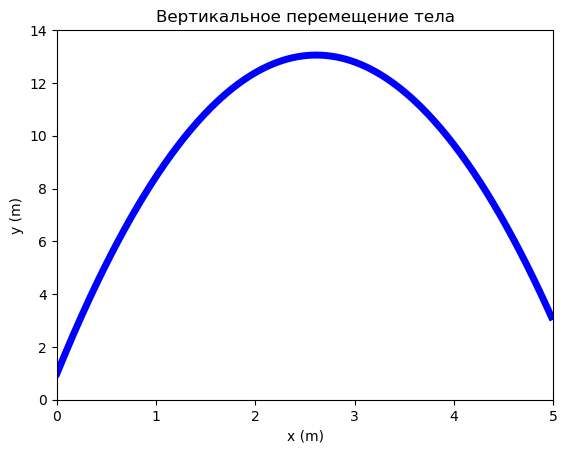

In [28]:
plt.figure()
plt.plot(s_x_list,s_y_list,'b-',lw=5)
plt.title('Вертикальное перемещение тела')
plt.xlabel('x (m)'); plt.ylabel('y (m)') # символ ; позволяет записывать несколь
plt.axis([0, s_end, 0, h_end+11])

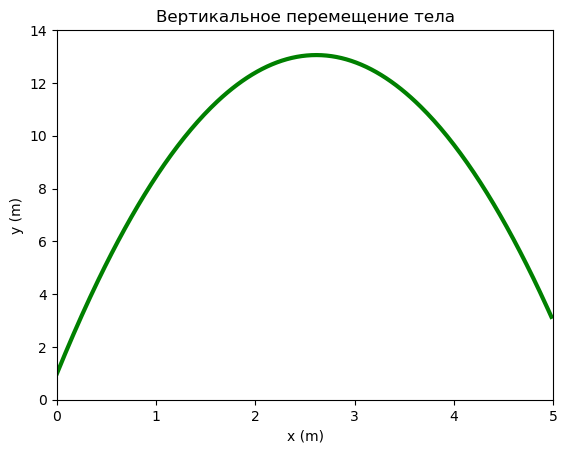

In [29]:
plt.figure()
plt.plot(s_x_array,s_y_array,color='green',lw=3)
plt.title('Вертикальное перемещение тела')
plt.xlabel('x (m)'); plt.ylabel('y (m)')
# альтернативный синтаксис для установки пределов по осям
plt.xlim(0, s_end)
plt.ylim(0, h_end+11);

# Задание 1.2. Определение момента времени касания телом земли

Для задачи о падении тела из Задания 1.1 $\color{red}\text{Найдите}$ момент времени касания телом
земли (время нахождения тела в воздухе).
Выполнение задания осуществите на основе двух подходов.

Подход 1 (**точное решение**): время касания телом земли находим как точное
решение уравнения $s$<sub>$y$</sub>($t$) = 0;

одход 2 (**приближенное решение**)
- Постройте последовательность $s_{y}$ на временном отрезке [0,$t_{stop}$] , чтобы момент касания тела земли t* попадал в выбранный отрезок, т.е.    t* $\in$ [0,$t_{stop}$].Отметим, что $t_{stop}$>T, где значение T задается в Задании 1.1.
- Найдите в построенной последовательности $s_{y}$ два соседних элемента последовательности, значения которых меняют знак. Т. е. найдите значение
индекса k, для которого $s_{y}[k]s_{y}[k+1]<0$ . Это будет означать, что 0 $\in$ ($s_{y}[k],s_{y}[k+1]).$
- Постройте прямую линию $s_{lin}(t)$, проходящую через две точки $(t[k],s_{y}[k])$ и  $(t[k+1],s_{y}[k+1])$ и найдите значение t* $\in$  $(t[k],t[k+1])$  из условия $s_{lin}(t*)=0$. Найденное значение t* , будет соответствовать точке (t*,0) на
прямой $s_{lin}(t)$. $\color{red}\text{Приведите}$ в документе формулы для прямой $s_{lin}(t)$ и для вычисления t* .
$\color{red}\text{Сравните}$ точное решение (Подход 1) и приближенное решение
(Подход 2), вычислив относительную ошибку.

Формула прямой $s_{lin}:$
$$\frac{x-t[k]}{t[k+1]-t[k]} = \frac{y-s_{y}[k]}{s_{y}[k+1]-s_{y}[k]}$$
Формула $t^*$:
$$t^* = \frac{-s_{y}[k]*(t[k+1]-t[k])}{s_{y}[k+1]-s_{y}[k]}+t[k]$$

Относительная ошибка двух подходов зависит от выбора шага интерполяции. В нашем случае ошибка составляет приблизительно $0.0002$%

## Выполнение Задания 1.2

 Подход 1 выполнения Задания 1.2.
- Для решения алгебраического уравнения $s_{y}(t)=0$ воспользуемся функцией solve из модуля sympy , которая предназначена для решения алгебраических уравнений и систем уравнений. Для выполнения функции solve предварительно с помощью функции symbols необходимо создать **символьную переменную**, относительно которой будет определено уравнение.

In [30]:
t = sympy.symbols('t')
result = sympy.solve(h_start+v0_y*t-g*t**2/2, t)
result

[-0.0637382309488101, 3.19970039267921]

In [31]:
t_star_exact = result[-1]
t_star_exact

3.19970039267921

**Спецификации функций sympy.symbols и sympy.solve:**

- Функция sympy.symbols объявляет символьные переменные для работы с математическими выражениями в аналитическом (символьном) виде.
- Функция sympy.solve решает уравнения и системы уравнений в символьном виде.

Примеры решений уравнений:

In [46]:
from sympy import symbols, solve
x = symbols('x')
equation = x**2 - 5*x + 6
solutions = solve(equation, x)
print(solutions)

[2, 3]


In [47]:
from sympy import symbols, solve

x, y = symbols('x y')

eq1 = 2*x + y - 7
eq2 = x - y - 2

solutions = solve([eq1, eq2], [x, y])

print(solutions)

{x: 3, y: 1}


In [48]:
# ?sympy.solve

$\color{red}\text{Выполните}$ Задание 1.2 на основе Подхода 2:

- для поиска индекса k, для которого $s_{y}[k]s_{y}[k+1]<0$, используйте цикл `for` по последовательности в $s_{y}$ сочетании с `enumerate`;
- для вычисления $t^*$ используйте полученную Вами формулу.

# Задание 1.3. Построение секущей, касательной и нормали к графику
# функции

$\color{red}\text{Постройте}$ в одной графической области:
- график траектории движения тела $(s_{x}(t),s_{y}(t))$ для t $\in$ [0,T] из Задания 1.1;
- график секущей прямой к траектории движения тела, проходящей через начальную точку при  t=0 и конечную точку при t=T;
- график касательной прямой к траектории движения тела в начальной точке при t=0 ;
- график нормальной прямой к траектории движения тела в начальной точке при t=0.

Построение графиков функций осуществляется по координатам точек графика. Для построения графиков прямых линий (секущая, касательная, нормаль) используйте только две точки!

## Выполнение Задания 1.3

Подготовим необходимые данные для построения секущей прямой к траектории
движения тела.

Воспользуемся векторно-параметрическим уравнением прямой для заданной
точки $p_{start}$, лежащей на прямой, и заданного направляющего вектора $\alpha$
$$p_{t}=p_{start}+at$$

Направляющий вектор можно определить как $\alpha$=$p_{end}$ - $p_{start}$, где точка $p_{end}$ лежит на прямой и отлична от $p_{start}$.

Введем новые переменные для описания начальной точки $p_{start}$  и конечной точки $p_{end}$ через их координаты. Для новых переменных используем тип массив (ndarray ) из numpy . Представление координат точек в виде массивов иногда эффективнее, чем представление в виде списков, для дальнейшей работы с координатами.

In [35]:
p_start = np.array([s_x_array[0],s_y_array[0]])
p_end = np.array([s_x_array[-1],s_y_array[-1]])
p_start, p_end

(array([0., 1.]), array([4.98333333, 3.13994275]))

Вычислим направляющий вектор:

In [36]:
a = p_end-p_start

Для построения графика прямой достаточно задания двух точек, лежащих на
прямой:

In [37]:
p = [p_start + a*t for t in [-1, 2]]
p = np.array(p)

Построим график траектории движения тела и график секущей прямой в одной
графической области:

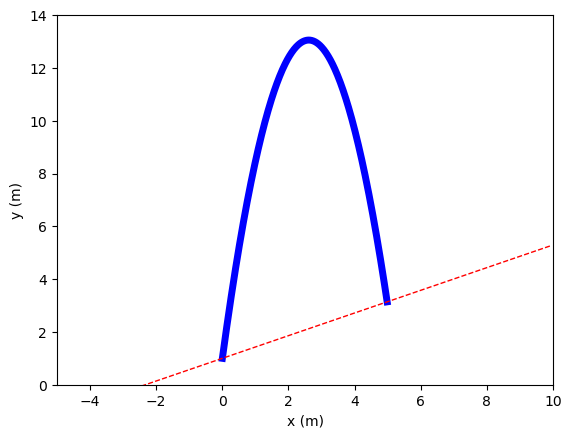

In [38]:
fig = plt.figure()
plt.plot(s_x_array,s_y_array,'b-',lw=5)
plt.plot(p[:,0],p[:,1],'--',color='red',lw=1) # обратите внимание не специальную
plt.xlabel('x (m)'); plt.ylabel('y (m)')
plt.axis([-5, s_end+5, 0, h_end+11]);

$\color{red}\text{Постройте}$ график касательной прямой к траектории движения
тела в одной графической области с траекторией движения и секущей прямой. Для
построения касательной прямой воспользуйтесь уравнением прямой по точке
$p_{start}(x_{start},y_{start})$ и угловому коэффициенту k:$$ y= k(x-x_{start})+y_{start}$$

In [39]:
K = math.tan(alpha)
Kas = [(t, K*(t-s_x_array[0])+s_y_array[0]) for t in [-1, 3]]
Kas = np.array(Kas)

Преобразовав уравнение прямой по точке и угловому коэффициенту $k$ получим:
$$kx-y-(kx_{start}-y_{start}) = 0 \text{ - общее уравнение прямой},$$
Следовательно вектор нормали к данной прямой будет иметь координаты $n(k, -1)$
Воспользуемся векторно-параметрическим заданием прямой по точке $p_{start}$ и вектору нормали $n$:
$$n(t) = p_{start}+nt$$

In [40]:
nVEC = np.array([K, -1])
n = [p_start + nVEC*t for t in [-1, 2]]
n = np.array(n)

Построим график траектории движения тела и график секущей прямой в одной
графической области:

(np.float64(-5.0), np.float64(10.0), np.float64(0.0), np.float64(14.0))

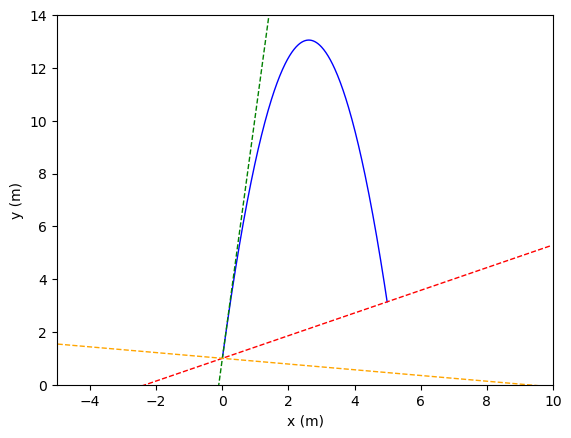

In [41]:
fig = plt.figure()
plt.plot(s_x_array, s_y_array, '-b', lw=1)
plt.plot(p[:,0],p[:,1], '--', color = 'red', lw=1)
plt.xlabel('x (m)'); plt.ylabel('y (m)')
plt.plot(Kas[:,0],Kas[:,1], '--', color = 'green', lw=1)
plt.plot(n[:,0],n[:,1], '--', color = 'orange', lw=1)

plt.axis([-5, s_end+5, 0, h_end+11])

# Задание 1.4. Построение графиков функций

$\color{red}\text{Постройте}$ графики функций на плоскости по координатам точек
согласно варианту. Функция задана:

 a) полярным уравнением   $\rho$= $\rho$($\phi$) в полярной системе координат ($\phi$,$\rho$);

Роза $$\rho = a \sin(2k\varphi), \, a \in \mathbb{R}, \, k \in \mathbb{N}$$

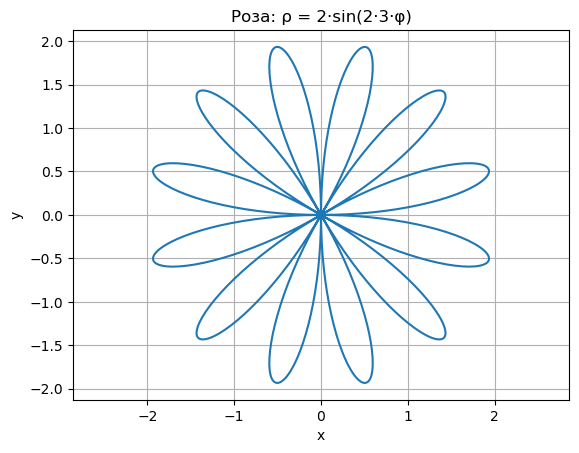

In [49]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

# Параметры для полярного уравнения (роза)
a = 2       # амплитуда
k = 3       # количество лепестков (для sin(2kφ) будет 4k лепестков при четном k?)

# Создаем массив углов от 0 до 2π
phi = np.linspace(0, 2*np.pi, 1000)

# Полярное уравнение: ρ = a·sin(2kφ)
rho = a * np.sin(2 * k * phi)

# Переводим в декартовы координаты
x = rho * np.cos(phi)
y = rho * np.sin(phi)

# Строим график
plt.plot(x, y)
plt.axis('equal')      # равный масштаб по осям
plt.grid(True)         # сетка
plt.title(f'Роза: ρ = {a}·sin(2·{k}·φ)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

б) параметрическими уравнениями x = x(t),y = y(t) в декартовой системе координат (x,y)

6) $$x = \ln \left( t + \sqrt{t^2 + 1} \right), \quad y = t\sqrt{t^2 + 1}$$

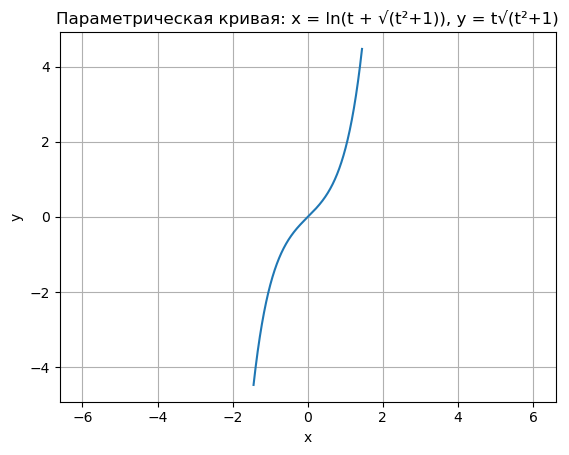

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# Параметрические уравнения из варианта 4б
# x = ln(t + sqrt(t^2 + 1))
# y = t * sqrt(t^2 + 1)

# Создаем массив значений t
# Выбираем диапазон, чтобы кривая была наглядной
t = np.linspace(-2, 2, 1000)

# Вычисляем координаты по формулам
x = np.log(t + np.sqrt(t**2 + 1))
y = t * np.sqrt(t**2 + 1)

# Строим график
plt.plot(x, y)
plt.axis('equal')      # равный масштаб по осям
plt.grid(True)         # сетка
plt.title('Параметрическая кривая: x = ln(t + √(t²+1)), y = t√(t²+1)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()